In [4]:
!pip install mlxtend==0.19.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4


In [6]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]



In [7]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

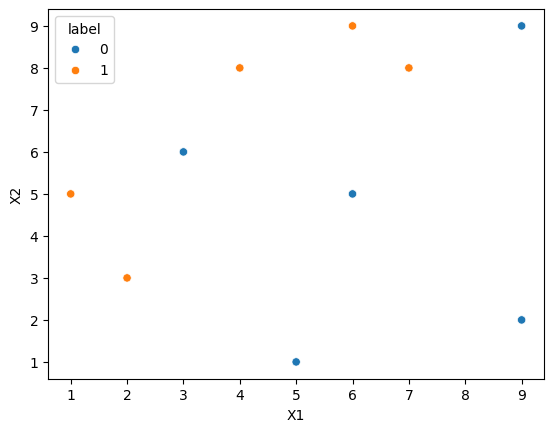

In [8]:
import seaborn as sns
sns.scatterplot(x= df['X1'],y = df['X2'],hue= df['label'])

In [9]:
#Assign all value as equal weights
df['weights'] = 1/df.shape[0]

In [10]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [77]:
from sklearn.tree import DecisionTreeClassifier
df1 = DecisionTreeClassifier(max_depth = 1)#shallow decision trees or decision stump
X= df.iloc[:,0:2].values
y= df.iloc[:,2].values

In [12]:
df1.fit(X,y) #Step 2 1st model

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

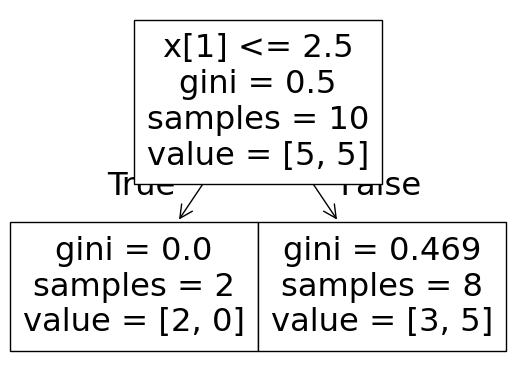

In [14]:
from sklearn.tree import plot_tree
plot_tree(df1)

<Axes: >

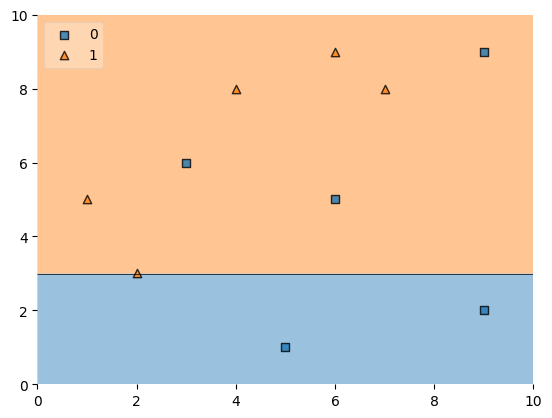

In [16]:
plot_decision_regions(X,y,df1,legend = 2)

In [17]:
df['y_pred'] = df1.predict(X)

In [18]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [19]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/error)

In [21]:
#Step 3 calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [25]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)


In [26]:
df['updated_weights'] = df.apply(update_row_weights,axis = 1)

In [27]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [28]:
df['updated_weights'].sum()


np.float64(0.9165153319682015)

In [29]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [30]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [31]:
df['normalized_weights'].sum()

np.float64(1.0)

In [32]:
df['cumsum_upper']= np.cumsum(df['normalized_weights'])
df['cumsum_lower']= np.cumsum(df['normalized_weights']) - df['normalized_weights']

In [33]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]


,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [34]:
def create_new_dataset(df): #Boosting

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices


In [35]:
index_values = create_new_dataset(df)


In [36]:
second_df = df.iloc[index_values,[0,1,2,3]]


In [37]:
second_df

,X1,X2,label,weights
4,5,1,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1
1,2,3,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1


In [38]:
dt2 = DecisionTreeClassifier(max_depth=1)


In [39]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [40]:
dt2.fit(X,y)


DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.625, 0.5, '  False')]

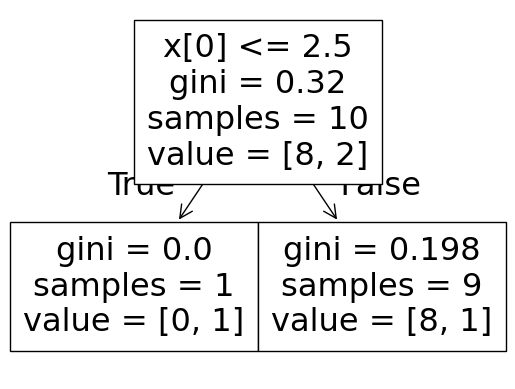

In [41]:
plot_tree(dt2)


<Axes: >

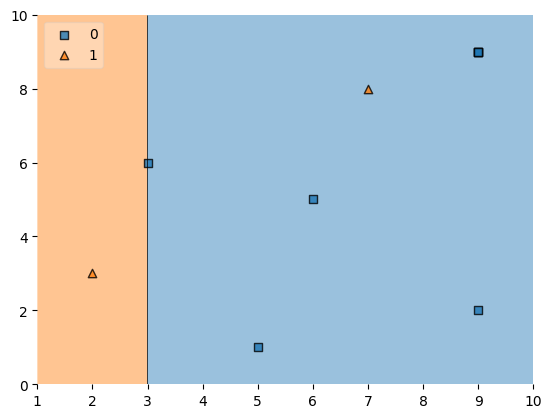

In [42]:
plot_decision_regions(X, y, clf=dt2, legend=2)


In [43]:
second_df['y_pred'] = dt2.predict(X)


In [44]:
second_df


,X1,X2,label,weights,y_pred
4,5,1,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
1,2,3,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0
8,9,9,0,0.1,0


In [45]:
alpha2 = calculate_model_weight(0.1)


In [46]:
alpha2

np.float64(1.0986122886681098)

In [47]:
# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)


In [48]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)


In [49]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
4,5,1,0,0.1,0,0.033622
7,7,8,1,0.1,0,0.297427
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622


In [50]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()


In [51]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
4,5,1,0,0.1,0,0.033622,0.056034
7,7,8,1,0.1,0,0.297427,0.495694
8,9,9,0,0.1,0,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
6,6,5,0,0.1,0,0.033622,0.056034
2,3,6,0,0.1,0,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034


In [52]:
second_df['nomalized_weights'].sum()


np.float64(0.9999999999999999)

In [53]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])


In [54]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']


In [55]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]


,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
4,5,1,0,0.1,0,0.056034,0.000000,0.056034
7,7,8,1,0.1,0,0.495694,0.056034,0.551728
8,9,9,0,0.1,0,0.056034,0.551728,0.607762
8,9,9,0,0.1,0,0.056034,0.607762,0.663796
1,2,3,1,0.1,1,0.056034,0.663796,0.719830
8,9,9,0,0.1,0,0.056034,0.719830,0.775864
9,9,2,0,0.1,0,0.056034,0.775864,0.831898
6,6,5,0,0.1,0,0.056034,0.831898,0.887932
2,3,6,0,0.1,0,0.056034,0.887932,0.943966
8,9,9,0,0.1,0,0.056034,0.943966,1.000000


In [56]:
index_values = create_new_dataset(second_df)


In [57]:
third_df = second_df.iloc[index_values,[0,1,2,3]]


In [58]:
third_df


,X1,X2,label,weights
9,9,2,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
8,9,9,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1


In [59]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

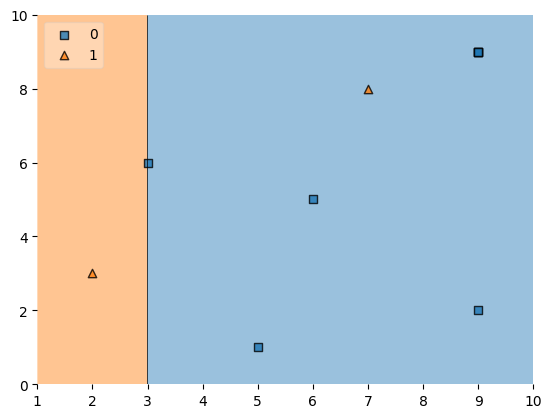

In [60]:
plot_decision_regions(X, y, clf=dt3, legend=2)


In [61]:
third_df['y_pred'] = dt3.predict(X)
third_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,1
8,9,9,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0


In [62]:

alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [63]:
print(alpha1,alpha2,alpha3)


0.42364893019360184 1.0986122886681098 -0.4236489301936017


##Prediction

In [65]:
query = np.array([1,5]).reshape(1,2)
df1.predict(query)

array([1])

In [68]:
dt2.predict(query)


array([1])

In [69]:
dt3.predict(query)


array([1])

In [70]:
alpha1*1 + alpha2*(1) + alpha3*(1)


np.float64(1.09861228866811)

In [71]:
np.sign(1.09)


np.float64(1.0)

In [73]:
query = np.array([9,9]).reshape(1,2)
df1.predict(query)

array([1])

In [74]:
dt2.predict(query)


array([0])

In [75]:
dt3.predict(query)
alpha1*(1) + alpha2*(-1) + alpha3*(-1)


np.float64(-0.2513144282809062)

In [76]:
np.sign(-0.25)


np.float64(-1.0)



---

### 🔧 **Core Idea Behind the Code**

You're manually simulating the **AdaBoost algorithm**:

#### 💡 What is AdaBoost?
AdaBoost stands for **Adaptive Boosting**, which is an ensemble learning method that combines multiple **weak learners** (typically shallow decision trees) into a strong classifier by **re-weighting** the data points.

---

### ✅ **Step-by-Step Breakdown**

| Step | Action | Explanation |
|------|--------|-------------|
| 1️⃣ | Created dataset with features `X1`, `X2` and binary labels | Your toy dataset simulates a classification problem |
| 2️⃣ | Plotted data using `Seaborn` | Helps visualize class separation |
| 3️⃣ | Initialized equal weights to all samples | This is step 1 of AdaBoost – equal importance |
| 4️⃣ | Trained a Decision Tree with `max_depth=1` | A weak learner (decision stump) |
| 5️⃣ | Plotted the decision boundary using `mlxtend` | To visually inspect the classifier’s behavior |
| 6️⃣ | Predicted and compared outputs with actual labels | Necessary to compute error |
| 7️⃣ | Computed the weighted error (here it’s 0.3) | Error used to calculate model confidence (alpha) |
| 8️⃣ | Calculated model weight (α) using AdaBoost formula | `α = 0.5 * log((1 - error) / error)` |
| 9️⃣ | Updated sample weights | More weight given to misclassified samples |
| 🔟 | Normalized weights so they sum up to 1 | Ensures valid probability distribution |
| 1️⃣1️⃣ | Calculated cumulative probability ranges | Required for probabilistic sampling |
| 1️⃣2️⃣ | Resampled data using updated weights | Creates a new dataset emphasizing hard samples |
| 1️⃣3️⃣ | Trained 2nd Decision Tree (dt2) on resampled data | Part of iterative AdaBoost cycle |

---

### 🧠 **Summary of the Concept**

- **Goal:** Improve model performance by focusing on **misclassified data**.
- **How:** Train weak models sequentially. Each one **pays more attention to errors** made by the previous model.
- **Why:** Misclassified points get higher weights → Next model learns harder examples better.
- **End Result:** A strong classifier made by combining weak learners weighted by their accuracy (α values).

---

### 💼 **Interview-Level Q&A**

#### ❓Q1: What is AdaBoost in simple terms?
**A:** AdaBoost is an ensemble technique that builds a strong classifier by combining multiple weak classifiers. Each model is trained in a way that gives more importance to the data points misclassified by previous models.

---

#### ❓Q2: Why do we assign weights to data points in AdaBoost?
**A:** We assign weights to make the model **focus more on the hard examples**. Initially, all weights are equal, but after each iteration, weights of **misclassified** points are **increased**, so the next model tries harder on those.

---

#### ❓Q3: How do you calculate the weight (α) of each model?
**A:**  
\[
\alpha = 0.5 \times \log\left(\frac{1 - \text{error}}{\text{error}}\right)
\]  
The more accurate the model, the higher its α, meaning it gets more say in the final prediction.

---

#### ❓Q4: What is the role of re-sampling with weights?
**A:** Re-sampling helps simulate a new dataset where **hard examples** (previously misclassified) are more likely to appear, allowing the next model to improve on those mistakes.

---

#### ❓Q5: Why do we normalize the weights?
**A:** So that the weights form a **probability distribution** (i.e., they sum to 1). This is necessary for **probabilistic sampling** in the next dataset creation.

---

#### ❓Q6: What does a Decision Tree with `max_depth=1` mean?
**A:** It’s called a **decision stump**. It makes only one split and is a weak learner – perfect for AdaBoost which relies on many such simple models.

---

#### ❓Q7: How does AdaBoost handle overfitting?
**A:** Surprisingly, AdaBoost often resists overfitting, especially with low-depth trees. It focuses on difficult patterns rather than memorizing all training data.

---

#### ❓Q8: Can you explain the decision boundary plot?
**A:** The plot shows how the trained decision stump divides the feature space. You can see how it tries to separate classes using just a single rule (e.g., `X2 <= 2.5`).

---

### 📌 Extra Tips for Interviews:
- Mention how AdaBoost is **adaptive** because it **changes sample weights** based on model performance.
- Say it's often used with **decision stumps**, but works with any classifier.
- Know that it's sensitive to **noisy data** and **outliers** due to exponential weight updates.

---

